In [1]:
import numpy as np
import pandas as pd 
import scipy as sp
import scipy.signal as spg
import cmath
import scipy.constants as const
import matplotlib.pyplot as plt
import sys
sys.path.append('/Users/leayamashiro/whispering_gallery_MAIN/calibrated/analysis')
import useful_functions as uf
import seaborn as sns 
sns.set_theme()


In [2]:
uf.find_plot_Q_peaks?

Signature: uf.find_plot_Q_peaks(Q_freq_data, n_peaks, plot=True)
Docstring: <no docstring>
File:      ~/whispering_gallery_MAIN/calibrated/analysis/useful_functions.py
Type:      function

In [3]:
uf.find_plot_Q_peaks_no_dup?

Signature: uf.find_plot_Q_peaks_no_dup(Q_freq_data, n_peaks, plot=True)
Docstring: <no docstring>
File:      ~/whispering_gallery_MAIN/calibrated/analysis/useful_functions.py
Type:      function

In [4]:
alumina_zotefoam = uf.fix_csv('EigenRadiusSweep_Al&ZotefoamContactModel_2.5to5.5GHz.csv', '/Users/leayamashiro/whispering_gallery_MAIN/calibrated/new_Q/Q_data/')
alumina_zotefoam

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1)
0,0.019056,2.500000e+09,2.300990+0.120102j,2.300990,9.579283
1,0.019056,2.500000e+09,2.301470+0.118395j,2.301470,9.719449
2,0.019056,2.500000e+09,2.302208+0.000443j,2.302208,2598.764480
3,0.019056,2.500000e+09,2.302459+0.000443j,2.302459,2595.928723
4,0.019056,2.500000e+09,2.315833+0.090437j,2.315833,12.803622
...,...,...,...,...,...
8395,0.076225,5.500000e+09,5.607012+0.007926j,5.607012,353.721377
8396,0.076225,5.500000e+09,5.614071+0.016858j,5.614071,166.510894
8397,0.076225,5.500000e+09,5.615189+0.009108j,5.615189,308.255028
8398,0.076225,5.500000e+09,5.616563+0.041967j,5.616563,66.915974


In [91]:
just_alumina = uf.fix_csv('EigenRadiusSweep_Al&NO_Zotefoam_2.5to5.5GHz.csv', '/Users/leayamashiro/whispering_gallery_MAIN/calibrated/new_Q/Q_data/')


New plan: 

1. just get main resonances by setting a threshold for Q-factor. And maybe do the same with the imaginary component of the eigenfrequency to make sure those match up. 

2. Once have table with all of the frequencies, want it so that I have one table for each of the zotefoam radii, where I have separated out the main resonances in to their separate columns. That way I can track where those resonances go over the course of adjusting the radius. 

I think the way to do this is to make: 
- do an inspection of each radius set by getting a bunch of peaks -- like around 40, and then figuring out some 

In [92]:
just_alumina

,% search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1)
0,2.500000e+09,2.303867+0.000451j,2.303867,2555.623285
1,2.500000e+09,2.304754+0.000456j,2.304754,2526.214326
2,2.500000e+09,2.305142+0.119320j,2.305142,9.659490
3,2.500000e+09,2.305514+0.119879j,2.305514,9.616028
4,2.500000e+09,2.317344+0.089775j,2.317344,12.906400
...,...,...,...,...
1675,5.500000e+09,5.606085+0.058361j,5.606085,48.029699
1676,5.500000e+09,5.608037+0.008465j,5.608037,331.250009
1677,5.500000e+09,5.611175+0.035847j,5.611175,78.266416
1678,5.500000e+09,5.612205+0.010116j,5.612205,277.404164


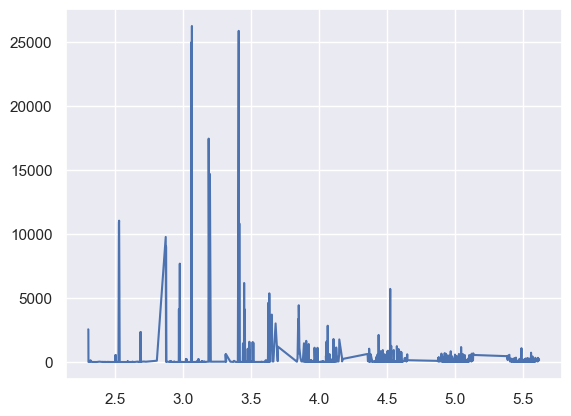

In [93]:
plt.plot(just_alumina['Frequency (GHz)'], just_alumina['Quality factor (1)'])

In [94]:
alumina_peaks = just_alumina[just_alumina['Quality factor (1)']>=3000].reset_index(drop=True)
alumina_peaks

,% search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1)
0,2.500000e+09,2.529201+0.000116j,2.529201,10886.747660
1,2.500000e+09,2.530838+0.000115j,2.530838,11031.027270
2,3.000000e+09,2.873249+0.000147j,2.873249,9761.626470
3,3.000000e+09,2.875583+0.000160j,2.875583,9012.052373
4,3.000000e+09,2.970204+0.000361j,2.970204,4119.369403
5,3.000000e+09,2.976651+0.000194j,2.976651,7678.571204
6,3.000000e+09,3.060040+0.000061j,3.060040,24931.664736
7,3.000000e+09,3.065609+0.000058j,3.065609,26220.346692
8,3.000000e+09,3.188710+0.000091j,3.188710,17433.217155
9,3.000000e+09,3.197803+0.000109j,3.197803,14671.994512


In [5]:
quarter_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(6)==0.019056]
third_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(6)==0.025408]
half_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(7)==0.0381125]
twothirds_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(6)==0.050817]
full_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(6)==0.076225]

yeah really just need to do a threshold thing rather than the find peaks because it is missing some peaks due to the way that the function works (distance from point next to it) -- it's missing some where there are two eigenvalues that are conjugates

In [74]:
quarter_R_Qpeaks = quarter_R[quarter_R['Quality factor (1)']>=10000].reset_index(drop=True)
third_R_Qpeaks = third_R[third_R['Quality factor (1)']>=7000].reset_index(drop=True)
half_R_Qpeaks = half_R[half_R['Quality factor (1)']>=10000].reset_index(drop=True)
twothirds_R_Qpeaks = twothirds_R[twothirds_R['Quality factor (1)']>=10000].reset_index(drop=True)
full_R_Qpeaks = full_R[full_R['Quality factor (1)']>=4000].reset_index(drop=True)

In [75]:
full_R_Qpeaks

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1),Freq rounded
0,0.076225,2.500000e+09,2.528290+0.000116j,2.528290,10909.796226,2.52829
1,0.076225,2.500000e+09,2.529899+0.000114j,2.529899,11047.639242,2.52990
2,0.076225,3.000000e+09,2.871407+0.000150j,2.871407,9580.564384,2.87141
3,0.076225,3.000000e+09,2.873661+0.000156j,2.873661,9187.540412,2.87366
4,0.076225,3.000000e+09,2.969044+0.000362j,2.969044,4103.808611,2.96904
5,0.076225,3.000000e+09,2.975817+0.000155j,2.975817,9595.058471,2.97582
6,0.076225,3.000000e+09,3.058627+0.000062j,3.058627,24522.532638,3.05863
7,0.076225,3.000000e+09,3.064110+0.000058j,3.064110,26208.375730,3.06411
8,0.076225,3.000000e+09,3.187654+0.000095j,3.187654,16753.080983,3.18765
9,0.076225,3.000000e+09,3.196782+0.000107j,3.196782,14903.051734,3.19678


In [48]:
quarter_R_Qpeaks

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1),Freq rounded
0,0.019056,2.500000e+09,2.527270+0.000110j,2.527270,11538.548092,2.52727
1,0.019056,2.500000e+09,2.528209+0.000110j,2.528209,11528.926570,2.52821
2,0.019056,3.000000e+09,2.872342+0.000133j,2.872342,10784.353903,2.87234
3,0.019056,3.000000e+09,2.873598+0.000137j,2.873598,10523.027438,2.87360
4,0.019056,3.000000e+09,2.970540+0.000134j,2.970540,11045.628029,2.97054
5,0.019056,3.000000e+09,2.971980+0.000039j,2.971980,38121.126055,2.97198
6,0.019056,3.000000e+09,3.060484+0.000044j,3.060484,34700.068670,3.06048
7,0.019056,3.000000e+09,3.061502+0.000039j,3.061502,39522.718314,3.06150
8,0.019056,3.000000e+09,3.188800+0.000036j,3.188800,44358.347161,3.18880
9,0.019056,3.000000e+09,3.193251+0.000036j,3.193251,44730.151506,3.19325


In [38]:
third_R_Qpeaks

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1),Freq rounded
1811,0.025408,2.500000e+09,2.527084+0.000109j,2.527084,11636.646056,2.52708
1812,0.025408,2.500000e+09,2.527941+0.000110j,2.527941,11479.176082,2.52794
1924,0.025408,3.000000e+09,2.873036+0.000147j,2.873036,9748.489799,2.87304
1925,0.025408,3.000000e+09,2.873241+0.000145j,2.873241,9887.118002,2.87324
2005,0.025408,3.000000e+09,2.969833+0.000185j,2.969833,8013.885757,2.96983
2009,0.025408,3.000000e+09,2.971673+0.000019j,2.971673,79424.859165,2.97167
2098,0.025408,3.000000e+09,3.059710+0.000046j,3.059710,33547.629753,3.05971
2102,0.025408,3.000000e+09,3.062964+0.000042j,3.062964,36821.935744,3.06296
2155,0.025408,3.000000e+09,3.187907+0.000029j,3.187907,54614.716230,3.18791
2157,0.025408,3.000000e+09,3.192902+0.000033j,3.192902,48748.839563,3.19290


In [39]:
half_R_Qpeaks

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1),Freq rounded
3490,0.038113,2.500000e+09,2.526884+0.000111j,2.526884,11399.638309,2.52688
3491,0.038113,2.500000e+09,2.527239+0.000110j,2.527239,11472.717448,2.52724
3604,0.038113,3.000000e+09,2.870592+0.000139j,2.870592,10297.060391,2.87059
3605,0.038113,3.000000e+09,2.873036+0.000139j,2.873036,10360.416277,2.87304
3685,0.038113,3.000000e+09,2.968589+0.000099j,2.968589,14991.026770,2.96859
3686,0.038113,3.000000e+09,2.970445+0.000029j,2.970445,50575.892744,2.97044
3775,0.038113,3.000000e+09,3.058250+0.000038j,3.058250,40598.558887,3.05825
3780,0.038113,3.000000e+09,3.060525+0.000037j,3.060525,41616.675706,3.06052
3835,0.038113,3.000000e+09,3.186949+0.000025j,3.186949,62858.287216,3.18695
3836,0.038113,3.000000e+09,3.189982+0.000031j,3.189982,50934.829418,3.18998


In [40]:
twothirds_R_Qpeaks

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1),Freq rounded
5170,0.050817,2.500000e+09,2.526875+0.000109j,2.526875,11587.081774,2.52687
5171,0.050817,2.500000e+09,2.527013+0.000110j,2.527013,11525.832177,2.52701
5284,0.050817,3.000000e+09,2.870120+0.000131j,2.870120,10953.438374,2.87012
5285,0.050817,3.000000e+09,2.872852+0.000138j,2.872852,10403.624633,2.87285
5363,0.050817,3.000000e+09,2.968526+0.000032j,2.968526,46706.459037,2.96853
5366,0.050817,3.000000e+09,2.969769+0.000040j,2.969769,36883.670781,2.96977
5454,0.050817,3.000000e+09,3.057661+0.000041j,3.057661,37042.946478,3.05766
5460,0.050817,3.000000e+09,3.060248+0.000047j,3.060248,32569.279175,3.06025
5514,0.050817,3.000000e+09,3.187040+0.000026j,3.187040,61819.954702,3.18704
5516,0.050817,3.000000e+09,3.189045+0.000022j,3.189045,71824.368090,3.18904


In [44]:
quarter_R_Qpeaks

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1),Freq rounded
130,0.019056,2.500000e+09,2.527270+0.000110j,2.527270,11538.548092,2.52727
131,0.019056,2.500000e+09,2.528209+0.000110j,2.528209,11528.926570,2.52821
244,0.019056,3.000000e+09,2.872342+0.000133j,2.872342,10784.353903,2.87234
245,0.019056,3.000000e+09,2.873598+0.000137j,2.873598,10523.027438,2.87360
325,0.019056,3.000000e+09,2.970540+0.000134j,2.970540,11045.628029,2.97054
330,0.019056,3.000000e+09,2.971980+0.000039j,2.971980,38121.126055,2.97198
419,0.019056,3.000000e+09,3.060484+0.000044j,3.060484,34700.068670,3.06048
420,0.019056,3.000000e+09,3.061502+0.000039j,3.061502,39522.718314,3.06150
475,0.019056,3.000000e+09,3.188800+0.000036j,3.188800,44358.347161,3.18880
477,0.019056,3.000000e+09,3.193251+0.000036j,3.193251,44730.151506,3.19325


In [95]:
alumina_peakfreqs = alumina_peaks['Frequency (GHz)'].iloc[0:18].drop(12)
quarter_R_peakfreqs = quarter_R_Qpeaks['Frequency (GHz)'].iloc[0:18].drop(12)
third_R_peakfreqs = third_R_Qpeaks['Frequency (GHz)']
half_R_peakfreqs = half_R_Qpeaks['Frequency (GHz)']
twothirds_R_peakfreqs = twothirds_R_Qpeaks['Frequency (GHz)'].iloc[0:17]
full_R_peakfreqs = full_R_Qpeaks['Frequency (GHz)']

In [54]:
len(quarter_R_peakfreqs)

16

In [70]:
quarter_R_peakfreqs.values

array([2.52726952, 2.52820941, 2.87234164, 2.87359847, 2.97054038,
       2.97198004, 3.06048365, 3.06150155, 3.18880012, 3.19325069,
       3.40692049, 3.41325879, 3.45094514, 3.62547338, 3.63204478,
       3.64273771, 3.64880508])

In [96]:
print(len(alumina_peakfreqs))
print(len(quarter_R_peakfreqs))
print(len(third_R_peakfreqs))
print(len(half_R_peakfreqs))
print(len(twothirds_R_peakfreqs))

17
17
17
17
17


In [97]:
radius_column = [0, 1/4, 1/3, 1/2, 2/3]

In [98]:
resonances_df = pd.DataFrame([alumina_peakfreqs.values, 
                              quarter_R_peakfreqs.values, 
                              third_R_peakfreqs.values, 
                              half_R_peakfreqs.values, 
                              twothirds_R_peakfreqs.values])
resonances_df.insert(0, 'Radius', radius_column)

In [99]:
resonances_df

,Radius,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,0.000000,2.529201,2.530838,2.873249,2.875583,2.970204,2.976651,3.060040,3.065609,3.188710,3.197803,3.409475,3.414007,3.455147,3.627450,3.634368,3.648997,3.652435
1,0.250000,2.527270,2.528209,2.872342,2.873598,2.970540,2.971980,3.060484,3.061502,3.188800,3.193251,3.406920,3.413259,3.450945,3.625473,3.632045,3.642738,3.648805
2,0.333333,2.527084,2.527941,2.873036,2.873241,2.969833,2.971673,3.059710,3.062964,3.187907,3.192902,3.407525,3.411023,3.452663,3.624767,3.630728,3.645074,3.647750
3,0.500000,2.526884,2.527239,2.870592,2.873036,2.968589,2.970445,3.058250,3.060525,3.186949,3.189982,3.404671,3.408845,3.442302,3.619576,3.628911,3.635994,3.647687
4,0.666667,2.526875,2.527013,2.870120,2.872852,2.968526,2.969769,3.057661,3.060248,3.187040,3.189045,3.404922,3.407486,3.446101,3.620756,3.625981,3.638705,3.643501


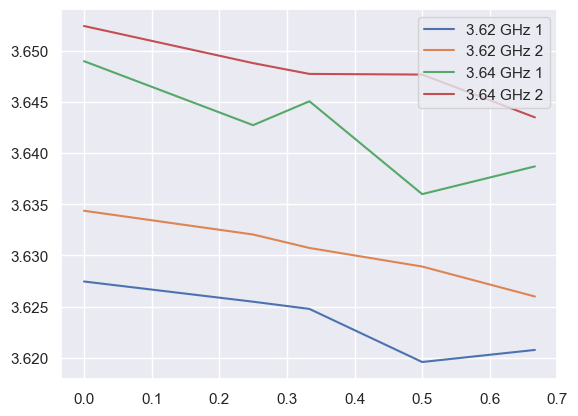

In [100]:
plt.figure()
# plt.plot(resonances_df['Radius'], resonances_df[0], label = '2.5 GHz 1')
# plt.plot(resonances_df['Radius'], resonances_df[1], label = '2.5 GHz 2')
# plt.plot(resonances_df['Radius'], resonances_df[2], label = '2.87 GHz 1')
# plt.plot(resonances_df['Radius'], resonances_df[3], label = '2.87 GHz 2')
# plt.plot(resonances_df['Radius'], resonances_df[4], label = '2.97 GHz 1')
# plt.plot(resonances_df['Radius'], resonances_df[5], label = '2.97 GHz 2')
# plt.plot(resonances_df['Radius'], resonances_df[6], label = '3.06 GHz 1')
# plt.plot(resonances_df['Radius'], resonances_df[7], label = '3.06 GHz 2')
# plt.plot(resonances_df['Radius'], resonances_df[8], label = '3.18 GHz 1')
# plt.plot(resonances_df['Radius'], resonances_df[9], label = '3.18 GHz 2')
# plt.plot(resonances_df['Radius'], resonances_df[10], label = '3.4 GHz 1')
# plt.plot(resonances_df['Radius'], resonances_df[11], label = '3.4 GHz 2')
# plt.plot(resonances_df['Radius'], resonances_df[12], label = '3.44 GHz')
plt.plot(resonances_df['Radius'], resonances_df[13], label = '3.62 GHz 1')
plt.plot(resonances_df['Radius'], resonances_df[14], label = '3.62 GHz 2')
plt.plot(resonances_df['Radius'], resonances_df[15], label = '3.64 GHz 1')
plt.plot(resonances_df['Radius'], resonances_df[16], label = '3.64 GHz 2')

plt.legend()




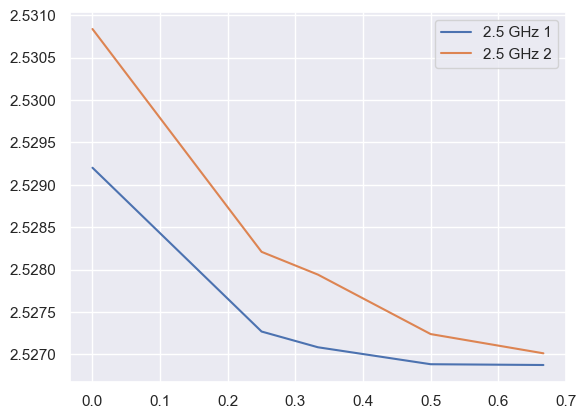

In [111]:
plt.plot(resonances_df['Radius'], resonances_df[0], label = '2.5 GHz 1')
plt.plot(resonances_df['Radius'], resonances_df[1], label = '2.5 GHz 2')
plt.legend()

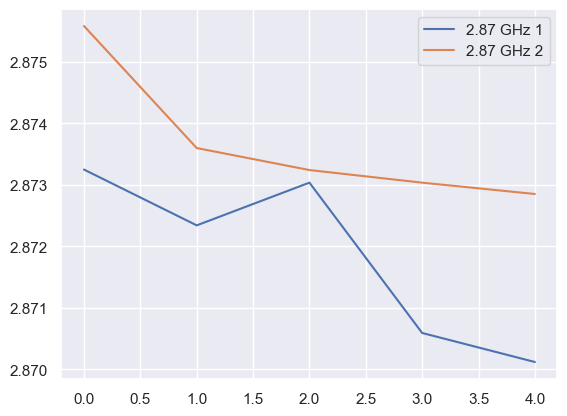

In [110]:
plt.plot(resonances_df.index, resonances_df[2], label = '2.87 GHz 1')
plt.plot(resonances_df.index, resonances_df[3], label = '2.87 GHz 2')
plt.legend()

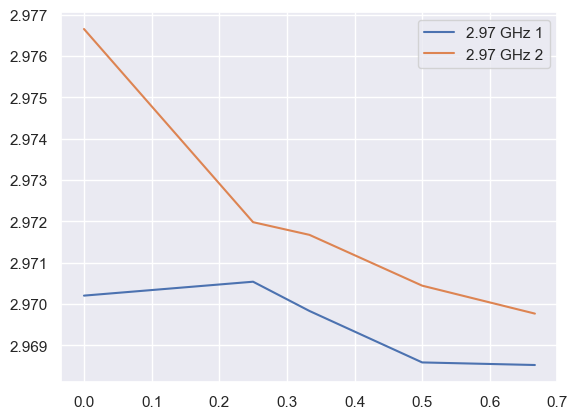

In [102]:

plt.plot(resonances_df['Radius'], resonances_df[4], label = '2.97 GHz 1')
plt.plot(resonances_df['Radius'], resonances_df[5], label = '2.97 GHz 2')
plt.legend()

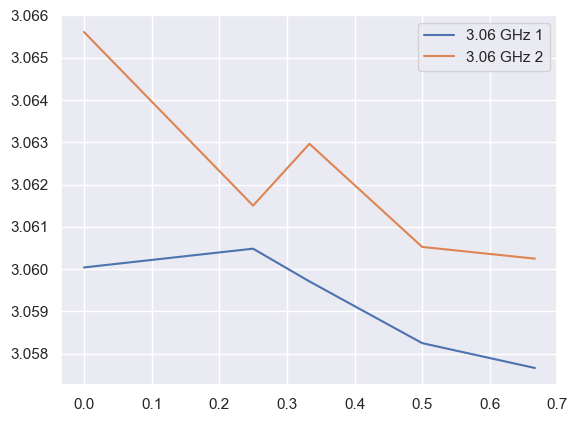

In [106]:
plt.plot(resonances_df['Radius'], resonances_df[6], label = '3.06 GHz 1')
plt.plot(resonances_df['Radius'], resonances_df[7], label = '3.06 GHz 2')
plt.legend()

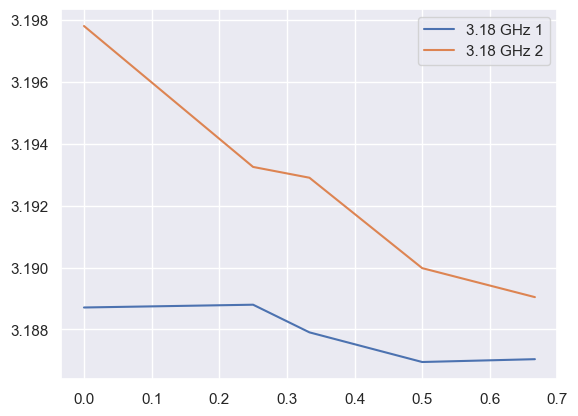

In [107]:
plt.plot(resonances_df['Radius'], resonances_df[8], label = '3.18 GHz 1')
plt.plot(resonances_df['Radius'], resonances_df[9], label = '3.18 GHz 2')
plt.legend()

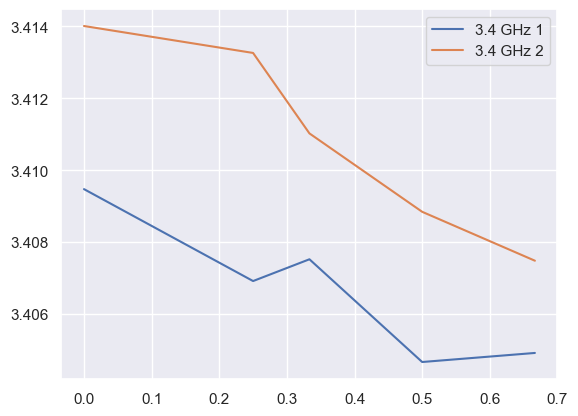

In [109]:
plt.plot(resonances_df['Radius'], resonances_df[10], label = '3.4 GHz 1')
plt.plot(resonances_df['Radius'], resonances_df[11], label = '3.4 GHz 2')
plt.legend()

In [77]:
radius_column = [1/4, 1/3, 1/2, 2/3]

In [76]:
resonances_df[0]

0    2.527270
1    2.527084
2    2.526884
3    2.526875
Name: 0, dtype: float64

In [62]:
third_R_peakfreqs

0     2.527084
1     2.527941
2     2.873036
3     2.873241
4     2.969833
5     2.971673
6     3.059710
7     3.062964
8     3.187907
9     3.192902
10    3.407525
11    3.411023
12    3.452663
13    3.624767
14    3.630728
15    3.645074
16    3.647750
Name: Frequency (GHz), dtype: float64

In [63]:
half_R_peakfreqs

0     2.526884
1     2.527239
2     2.870592
3     2.873036
4     2.968589
5     2.970445
6     3.058250
7     3.060525
8     3.186949
9     3.189982
10    3.404671
11    3.408845
12    3.442302
13    3.619576
14    3.628911
15    3.635994
16    3.647687
Name: Frequency (GHz), dtype: float64

In [61]:
twothirds_R_peakfreqs

0     2.526875
1     2.527013
2     2.870120
3     2.872852
4     2.968526
5     2.969769
6     3.057661
7     3.060248
8     3.187040
9     3.189045
10    3.404922
11    3.407486
12    3.446101
13    3.620756
14    3.625981
15    3.638705
16    3.643501
17    3.837943
Name: Frequency (GHz), dtype: float64

In [60]:
third_R_peakfreqs

0     2.527084
1     2.527941
2     2.873036
3     2.873241
4     2.969833
5     2.971673
6     3.059710
7     3.062964
8     3.187907
9     3.192902
10    3.407525
11    3.411023
12    3.452663
13    3.624767
14    3.630728
15    3.645074
16    3.647750
Name: Frequency (GHz), dtype: float64

In [10]:
Q_peaks, _ = spg.find_peaks(quarter_R['Quality factor (1)'])
Q_peaks_df = quarter_R.iloc[Q_peaks].sort_values(['Quality factor (1)'], ascending=False)
top_peaks = Q_peaks_df.iloc[0:30]
top_peaks

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1)
477,0.019056,3.000000e+09,3.193251+0.000036j,3.193251,44730.151506
475,0.019056,3.000000e+09,3.188800+0.000036j,3.188800,44358.347161
420,0.019056,3.000000e+09,3.061502+0.000039j,3.061502,39522.718314
330,0.019056,3.000000e+09,2.971980+0.000039j,2.971980,38121.126055
501,0.019056,3.500000e+09,3.406920+0.000079j,3.406920,21533.539236
706,0.019056,3.500000e+09,3.632045+0.000086j,3.632045,21089.975647
536,0.019056,3.500000e+09,3.450945+0.000093j,3.450945,18504.550968
522,0.019056,3.500000e+09,3.443743+0.000104j,3.443743,16498.940826
503,0.019056,3.500000e+09,3.413259+0.000113j,3.413259,15082.659460
712,0.019056,3.500000e+09,3.648805+0.000125j,3.648805,14651.433851


In [9]:
Q_peaks, _ = spg.find_peaks(third_R['Quality factor (1)'])
Q_peaks_df = third_R.iloc[Q_peaks].sort_values(['Quality factor (1)'], ascending=False)
top_peaks = Q_peaks_df.iloc[0:10]
top_peaks

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1)
2009,0.025408,3.000000e+09,2.971673+0.000019j,2.971673,79424.859165
2155,0.025408,3.000000e+09,3.187907+0.000029j,3.187907,54614.716230
2157,0.025408,3.000000e+09,3.192902+0.000033j,3.192902,48748.839563
2102,0.025408,3.000000e+09,3.062964+0.000042j,3.062964,36821.935744
2098,0.025408,3.000000e+09,3.059710+0.000046j,3.059710,33547.629753
2182,0.025408,3.500000e+09,3.411023+0.000084j,3.411023,20305.070604
2391,0.025408,3.500000e+09,3.645074+0.000146j,3.645074,12481.142565
1811,0.025408,2.500000e+09,2.527084+0.000109j,2.527084,11636.646056
2383,0.025408,3.500000e+09,3.624767+0.000161j,3.624767,11235.013442
1925,0.025408,3.000000e+09,2.873241+0.000145j,2.873241,9887.118002


In [18]:
quarter_R_reduced, quarter_R_peaks = uf.find_plot_Q_peaks(quarter_R, n_peaks=20, plot=False)
third_R_reduced, third_R_peaks = uf.find_plot_Q_peaks(third_R, n_peaks=20, plot=False)
half_R_reduced, half_R_peaks = uf.find_plot_Q_peaks(half_R, n_peaks=20, plot=False)
twothirds_R_reduced, twothirds_R_peaks = uf.find_plot_Q_peaks(twothirds_R, n_peaks=20, plot=False)
full_R_reduced, full_R_peaks = uf.find_plot_Q_peaks(full_R, n_peaks=20, plot=False)

/Users/leayamashiro/whispering_gallery_MAIN/calibrated/analysis/useful_functions.py:165: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q_freq_data['Freq rounded'] = Q_freq_data['Frequency (GHz)'].round(5)
/Users/leayamashiro/whispering_gallery_MAIN/calibrated/analysis/useful_functions.py:165: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q_freq_data['Freq rounded'] = Q_freq_data['Frequency (GHz)'].round(5)
/Users/leayamashiro/whispering_gallery_MAIN/calibrated/analysis/useful_functions.py:165: SettingWithCo

In [15]:
quarter_R_peaks

,index,cf,freqs,Q
0,477,3.000000e+09,3.193251,44730.151506
1,475,3.000000e+09,3.188800,44358.347161
2,420,3.000000e+09,3.061502,39522.718314
3,330,3.000000e+09,2.971980,38121.126055
4,501,3.500000e+09,3.406920,21533.539236
5,706,3.500000e+09,3.632045,21089.975647
6,536,3.500000e+09,3.450945,18504.550968
7,522,3.500000e+09,3.443743,16498.940826
8,503,3.500000e+09,3.413259,15082.659460
9,712,3.500000e+09,3.648805,14651.433851


In [14]:
full_R_peaks

,index,cf,freqs,Q
0,7222,3.500000e+09,3.408404,28536.442258
1,7143,3.000000e+09,3.064110,26208.375730
2,7138,3.000000e+09,3.058627,24522.532638
3,7196,3.000000e+09,3.187654,16753.080983
4,7198,3.000000e+09,3.196782,14903.051734
5,6853,2.500000e+09,2.529899,11047.639242
6,7225,3.500000e+09,3.412799,10825.403430
7,7057,3.000000e+09,2.975817,9595.058471
8,6962,3.000000e+09,2.871407,9580.564384
9,6964,3.000000e+09,2.873661,9187.540412


In [19]:
quarter_R_peaks_ND = uf.find_plot_Q_peaks_no_dup(quarter_R, n_peaks=20, plot=False)


third_R_reduced, third_R_peaks = uf.find_plot_Q_peaks_no_dup(third_R, n_peaks=20, plot=False)
half_R_reduced, half_R_peaks = uf.find_plot_Q_peaks_no_dup(half_R, n_peaks=20, plot=False)
twothirds_R_reduced, twothirds_R_peaks = uf.find_plot_Q_peaks_no_dup(twothirds_R, n_peaks=20, plot=False)
full_R_reduced, full_R_peaks = uf.find_plot_Q_peaks_no_dup(full_R, n_peaks=20, plot=False)

KeyError: "None of [Index([   2,    6,    9,   11,   13,   16,   18,   22,   27,   31,\n       ...\n       1647, 1652, 1654, 1660, 1662, 1666, 1669, 1673, 1676, 1678],\n      dtype='int64', length=553)] are in the [index]"

In [16]:
quarter_R_peaks_ND == quarter_R_peaks

,index,cf,freqs,Q
0,True,True,True,True
1,True,True,True,True
2,True,True,True,True
3,True,True,True,True
4,True,True,True,True
5,True,True,True,True
6,True,True,True,True
7,True,True,True,True
8,True,True,True,True
9,True,True,True,True


In [12]:
quarter_R_peaks

,index,cf,freqs,Q
0,477,3.000000e+09,3.193251,44730.151506
1,475,3.000000e+09,3.188800,44358.347161
2,420,3.000000e+09,3.061502,39522.718314
3,330,3.000000e+09,2.971980,38121.126055
4,501,3.500000e+09,3.406920,21533.539236
5,706,3.500000e+09,3.632045,21089.975647
6,536,3.500000e+09,3.450945,18504.550968
7,522,3.500000e+09,3.443743,16498.940826
8,503,3.500000e+09,3.413259,15082.659460
9,712,3.500000e+09,3.648805,14651.433851


In [24]:
print(np.average(quarter_R_peaks['Q']))
print(np.average(third_R_peaks['Q']))
print(np.average(half_R_peaks['Q']))
print(np.average(twothirds_R_peaks['Q']))
print(np.average(full_R_peaks['Q']))

17907.11995790715
18427.980984952046
18871.383814844878
22785.193263493205
10105.338172002557


In [26]:
print(np.average(quarter_R_reduced['Quality factor (1)']))
print(np.average(third_R_reduced['Quality factor (1)']))
print(np.average(half_R_reduced['Quality factor (1)']))
print(np.average(twothirds_R_reduced['Quality factor (1)']))
print(np.average(full_R_reduced['Quality factor (1)']))

354.1046149970018
342.6294751722738
400.569083303788
409.73413703663505
205.35837642142445


Okay yeah maybe this is interesting. But also there could be things about the way that I entered in the Zotefoam parameters that aren't perfect, or different. And the Zotefoam interference could be frequency dependent... 

Also wonder for the peak averages what happens when I take a larger sample of "peaks"...

Also, thinking about Jackson's equation, since there is a slight index of refraction, having some not completely permittive material physically up against the alumina could be helping further contain the fields, which is why there might be this sweet spot at 2/3 R. Because that's about where the best lobes happen in the whispering gallery modes. So it would make sense that for the r = R, it drops back down. Interesting! 

In [14]:
quarter_R_peaks

,index,cf,freqs,Q
0,477,3.000000e+09,3.193251,44730.151506
1,475,3.000000e+09,3.188800,44358.347161
2,420,3.000000e+09,3.061502,39522.718314
3,330,3.000000e+09,2.971980,38121.126055
4,501,3.500000e+09,3.406920,21533.539236
5,706,3.500000e+09,3.632045,21089.975647
6,536,3.500000e+09,3.450945,18504.550968
7,522,3.500000e+09,3.443743,16498.940826
8,503,3.500000e+09,3.413259,15082.659460
9,712,3.500000e+09,3.648805,14651.433851


In [ ]:
print(np.average(quarter_R_))
print(np.average(third_R_peaks))
print(np.average(half_R_peaks))
print(np.average(twothirds_R_peaks))
print(np.average(full_R_peaks))

Okay that's interesting. So the quality factor 

In [8]:
quarter_R

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1),Freq rounded
0,0.019056,2.500000e+09,2.300990+0.120102j,2.300990,9.579283,2.30099
1,0.019056,2.500000e+09,2.301470+0.118395j,2.301470,9.719449,2.30147
2,0.019056,2.500000e+09,2.302208+0.000443j,2.302208,2598.764480,2.30221
3,0.019056,2.500000e+09,2.302459+0.000443j,2.302459,2595.928723,2.30246
4,0.019056,2.500000e+09,2.315833+0.090437j,2.315833,12.803622,2.31583
...,...,...,...,...,...,...
1675,0.019056,5.500000e+09,5.604099+0.005926j,5.604099,472.842192,5.60410
1676,0.019056,5.500000e+09,5.608654+0.039165j,5.608654,71.602872,5.60865
1677,0.019056,5.500000e+09,5.610166+0.008512j,5.610166,329.560179,5.61017
1678,0.019056,5.500000e+09,5.611141+0.005523j,5.611141,508.020939,5.61114


In [9]:
quarter_R_reduced

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1),Freq rounded
0,0.019056,2.500000e+09,2.300990+0.120102j,2.300990,9.579283,2.30099
1,0.019056,2.500000e+09,2.301470+0.118395j,2.301470,9.719449,2.30147
2,0.019056,2.500000e+09,2.302208+0.000443j,2.302208,2598.764480,2.30221
3,0.019056,2.500000e+09,2.302459+0.000443j,2.302459,2595.928723,2.30246
4,0.019056,2.500000e+09,2.315833+0.090437j,2.315833,12.803622,2.31583
...,...,...,...,...,...,...
1675,0.019056,5.500000e+09,5.604099+0.005926j,5.604099,472.842192,5.60410
1676,0.019056,5.500000e+09,5.608654+0.039165j,5.608654,71.602872,5.60865
1677,0.019056,5.500000e+09,5.610166+0.008512j,5.610166,329.560179,5.61017
1678,0.019056,5.500000e+09,5.611141+0.005523j,5.611141,508.020939,5.61114


In [11]:
quarter_R_reduced, quarter_R_peaks = uf.find_plot_Q_peaks(quarter_R, n_peaks=30, plot=False)
third_R_reduced, third_R_peaks = uf.find_plot_Q_peaks(third_R, n_peaks=20, plot=False)
half_R_reduced, half_R_peaks = uf.find_plot_Q_peaks(half_R, n_peaks=20, plot=False)
twothirds_R_reduced, twothirds_R_peaks = uf.find_plot_Q_peaks(twothirds_R, n_peaks=20, plot=False)
full_R_reduced, full_R_peaks = uf.find_plot_Q_peaks(full_R, n_peaks=20, plot=False)

/Users/leayamashiro/whispering_gallery_MAIN/calibrated/analysis/useful_functions.py:165: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q_freq_data['Freq rounded'] = Q_freq_data['Frequency (GHz)'].round(5)
/Users/leayamashiro/whispering_gallery_MAIN/calibrated/analysis/useful_functions.py:165: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q_freq_data['Freq rounded'] = Q_freq_data['Frequency (GHz)'].round(5)
/Users/leayamashiro/whispering_gallery_MAIN/calibrated/analysis/useful_functions.py:165: SettingWithCo

In [ ]:
print(np.average())

In [12]:
quarter_R_reduced[(quarter_R_reduced['Frequency (GHz)']>2.8)&(quarter_R_reduced['Frequency (GHz)']<2.92)]

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1),Freq rounded
240,0.019056,3.000000e+09,2.803900+0.013158j,2.803900,106.545333,2.80390
241,0.019056,3.000000e+09,2.805139+0.013190j,2.805139,106.334119,2.80514
242,0.019056,3.000000e+09,2.867643+0.035868j,2.867643,39.974946,2.86764
243,0.019056,3.000000e+09,2.867964+0.035764j,2.867964,40.096126,2.86796
244,0.019056,3.000000e+09,2.872342+0.000133j,2.872342,10784.353903,2.87234
245,0.019056,3.000000e+09,2.873598+0.000137j,2.873598,10523.027438,2.87360
246,0.019056,3.000000e+09,2.896572+0.137128j,2.896572,10.561562,2.89657
247,0.019056,3.000000e+09,2.896816+0.138160j,2.896816,10.483580,2.89682
248,0.019056,3.000000e+09,2.897653+0.026825j,2.897653,54.010366,2.89765
249,0.019056,3.000000e+09,2.897928+0.137725j,2.897928,10.520691,2.89793


#### This is as of EOD July 3, 2025. Have a new plan ^^

In [99]:
quarter_R_reduced['Frequency (GHz)'].iloc[244]

2.872341637841935

In [95]:
quarter_R_peaks.sort_values(['freqs'], ascending=True).to_csv('Q_data/quarter_R_peaks.csv', index=False)
third_R_peaks.sort_values(['freqs'], ascending=True).to_csv('Q_data/third_R_peaks.csv', index=False)
half_R_peaks.sort_values(['freqs'], ascending=True).to_csv('Q_data/half_R_peaks.csv', index=False)
twothirds_R_peaks.sort_values(['freqs'], ascending=True).to_csv('Q_data/twothirds_R_peaks.csv', index=False)
full_R_peaks.sort_values(['freqs'], ascending=True).to_csv('Q_data/full_R_peaks.csv', index=False)


In [ ]:
third_R_peaks.sort_values(['freqs'], ascending=True)

,index,cf,freqs,Q
23,1682,2.500000e+09,2.301967,2607.983638
7,1811,2.500000e+09,2.527084,11636.646056
27,1906,2.500000e+09,2.687035,2330.679610
28,1909,2.500000e+09,2.688709,2314.850600
9,1925,3.000000e+09,2.873241,9887.118002
11,2005,3.000000e+09,2.969833,8013.885757
0,2009,3.000000e+09,2.971673,79424.859165
4,2098,3.000000e+09,3.059710,33547.629753
3,2102,3.000000e+09,3.062964,36821.935744
1,2155,3.000000e+09,3.187907,54614.716230


In [65]:
al_zote['Freq rounded'] = al_zote['Frequency (GHz)'].round(6)
alumina_zotefoam = al_zote.drop_duplicates(subset='Freq rounded', keep='first')
alumina_zotefoam

NameError: name 'al_zote' is not defined

1680 rows per radius of zotefoam

In [66]:
quarter_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(6)==0.019056]
third_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(6)==0.025408]
half_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(7)==0.0381125]
twothirds_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(6)==0.050817]
full_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(6)==0.076225]

Plan: get data into a situation where I can plot radius vs. frequency for one peak... or for multiple

(2.5, 4.0)

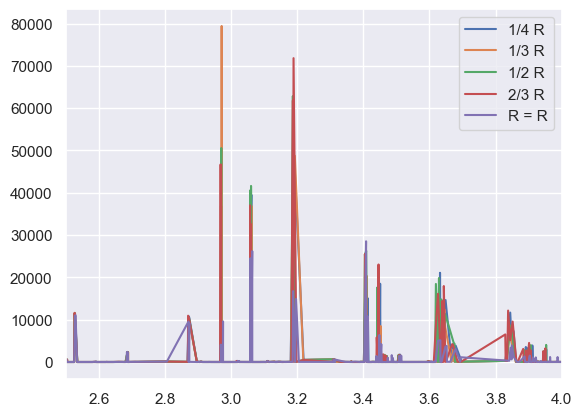

In [67]:
plt.plot(quarter_R['Frequency (GHz)'], quarter_R['Quality factor (1)'], label = '1/4 R')
plt.plot(third_R['Frequency (GHz)'], third_R['Quality factor (1)'], label = '1/3 R')
plt.plot(half_R['Frequency (GHz)'], half_R['Quality factor (1)'], label = '1/2 R')
plt.plot(twothirds_R['Frequency (GHz)'], twothirds_R['Quality factor (1)'], label = '2/3 R')
plt.plot(full_R['Frequency (GHz)'], full_R['Quality factor (1)'], label = 'R = R')
plt.legend()

plt.xlim(2.5, 4.0)

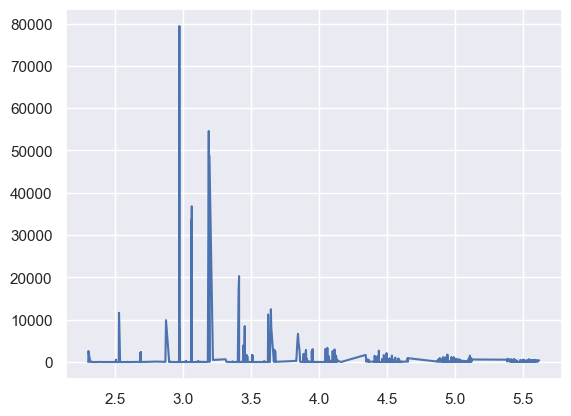

In [68]:
plt.plot(third_R['Frequency (GHz)'], third_R['Quality factor (1)'], label = 'R = R')

In [69]:
quarter_R_peaks

,index,cf,freqs,Q
0,477,3.000000e+09,3.193251,44730.151506
1,475,3.000000e+09,3.188800,44358.347161
2,420,3.000000e+09,3.061502,39522.718314
3,330,3.000000e+09,2.971980,38121.126055
4,501,3.500000e+09,3.406920,21533.539236
5,706,3.500000e+09,3.632045,21089.975647
6,536,3.500000e+09,3.450945,18504.550968
7,522,3.500000e+09,3.443743,16498.940826
8,503,3.500000e+09,3.413259,15082.659460
9,712,3.500000e+09,3.648805,14651.433851


In [70]:
third_R_peaks

,index,cf,freqs,Q
0,2009,3.000000e+09,2.971673,79424.859165
1,2155,3.000000e+09,3.187907,54614.716230
2,2157,3.000000e+09,3.192902,48748.839563
3,2102,3.000000e+09,3.062964,36821.935744
4,2098,3.000000e+09,3.059710,33547.629753
5,2182,3.500000e+09,3.411023,20305.070604
6,2391,3.500000e+09,3.645074,12481.142565
7,1811,2.500000e+09,2.527084,11636.646056
8,2383,3.500000e+09,3.624767,11235.013442
9,1925,3.000000e+09,2.873241,9887.118002


Text(0, 0.5, 'Q Factor')

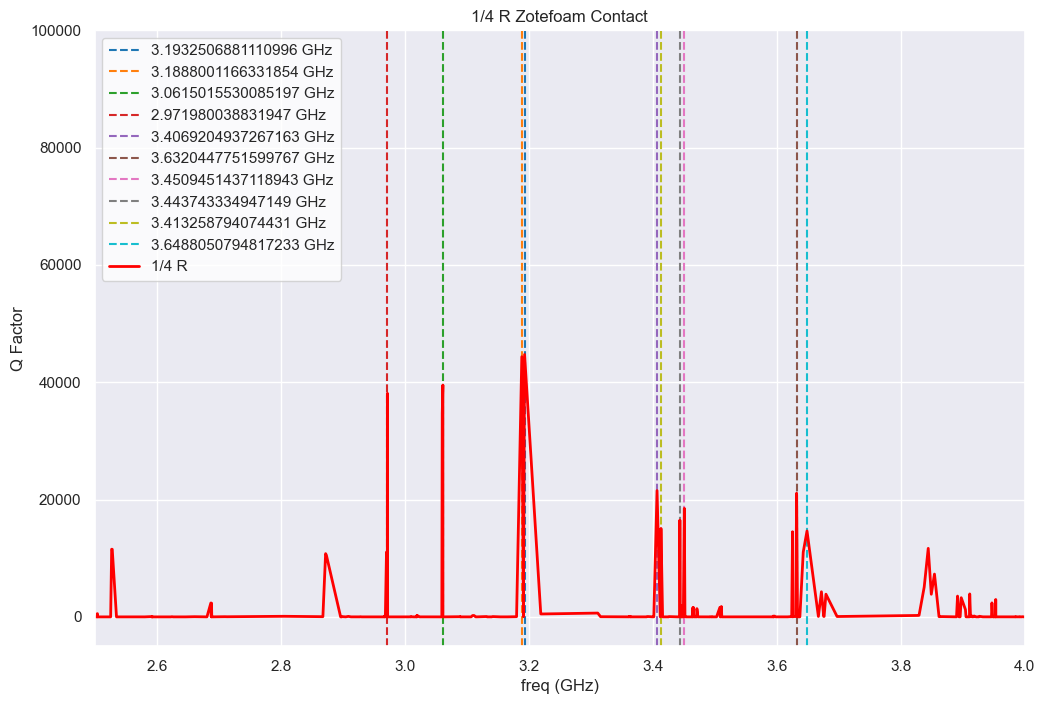

In [83]:
plt.figure(figsize = (12, 8))
cmap = plt.get_cmap('tab10')
for i in range(10):
    color = cmap(i % cmap.N)
    plt.axvline(x=quarter_R_peaks['freqs'].loc[i], 
                ymin=0, ymax = 50000, 
                label = str(quarter_R_peaks['freqs'].loc[i]) + ' GHz', 
                ls='dashed', color = color)
plt.plot(quarter_R['Frequency (GHz)'], quarter_R['Quality factor (1)'], label = '1/4 R', lw=2, color = 'red')
plt.legend(facecolor = 'white')
plt.xlim(2.5, 4)
plt.ylim(-5000, 100000)
plt.title('1/4 R Zotefoam Contact')
plt.xlabel('freq (GHz)')
plt.ylabel('Q Factor')

Text(0, 0.5, 'Q Factor')

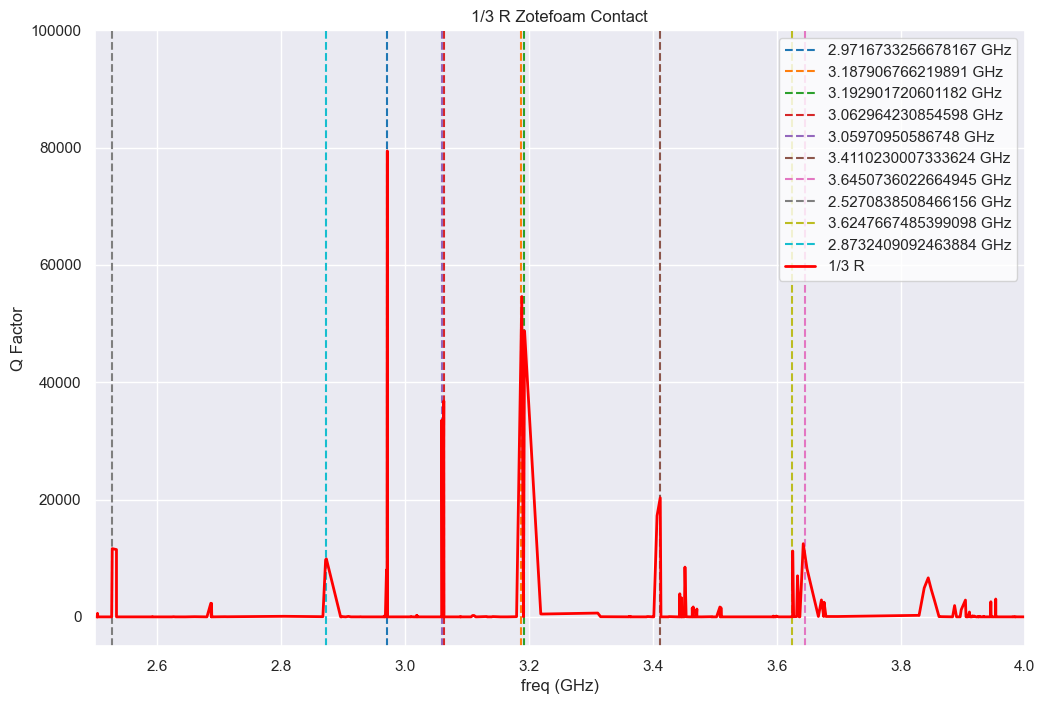

In [84]:
plt.figure(figsize = (12, 8))
cmap = plt.get_cmap('tab10')
for i in range(10):
    color = cmap(i % cmap.N)
    plt.axvline(x=third_R_peaks['freqs'].loc[i], 
                ymin=0, ymax = 100000, 
                label = str(third_R_peaks['freqs'].loc[i]) + ' GHz', 
                ls='dashed', color = color)
plt.plot(quarter_R['Frequency (GHz)'], third_R_reduced['Quality factor (1)'], label = '1/3 R', color = 'red', lw = 2)
plt.legend(facecolor='white')
plt.xlim(2.5, 4)
plt.ylim(-5000, 100000)
plt.title('1/3 R Zotefoam Contact')
plt.xlabel('freq (GHz)')
plt.ylabel('Q Factor')

Text(0, 0.5, 'Q Factor')

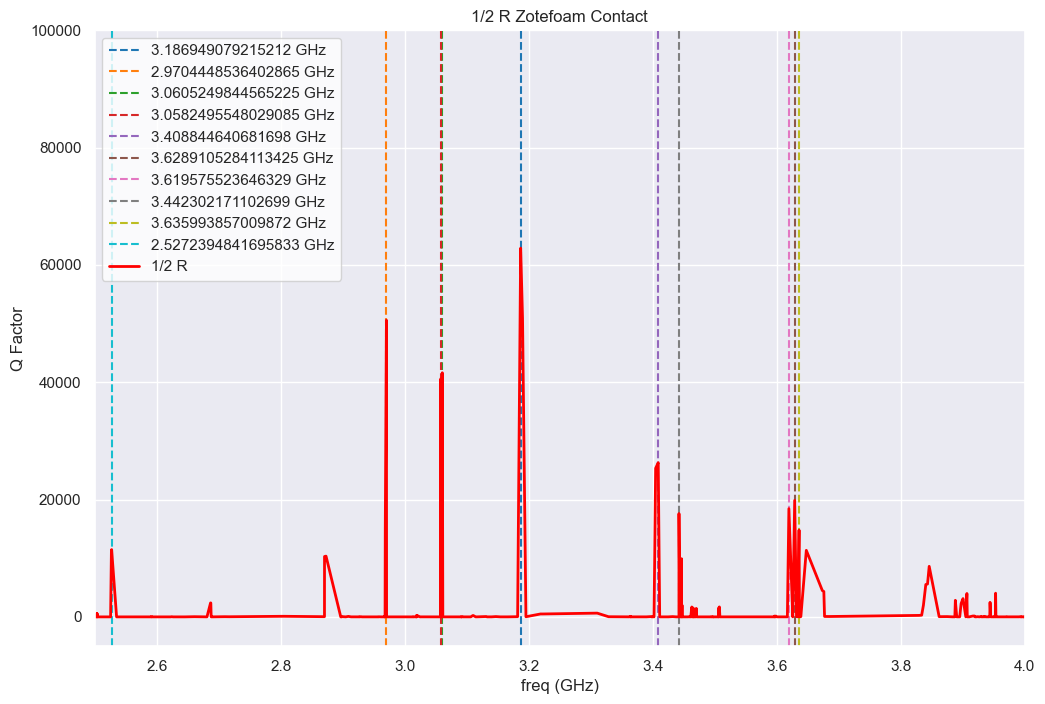

In [85]:
plt.figure(figsize = (12, 8))
cmap = plt.get_cmap('tab10')
for i in range(10):
    color = cmap(i % cmap.N)
    plt.axvline(x=half_R_peaks['freqs'].loc[i], 
                ymin=0, ymax = 100000, 
                label = str(half_R_peaks['freqs'].loc[i]) + ' GHz', 
                ls='dashed', color = color)
plt.plot(half_R_reduced['Frequency (GHz)'], half_R_reduced['Quality factor (1)'], label = '1/2 R', color = 'red', lw = 2)
plt.legend(facecolor='white')
plt.xlim(2.5, 4)
plt.ylim(-5000, 100000)
plt.title('1/2 R Zotefoam Contact')
plt.xlabel('freq (GHz)')
plt.ylabel('Q Factor')

Text(0, 0.5, 'Q Factor')

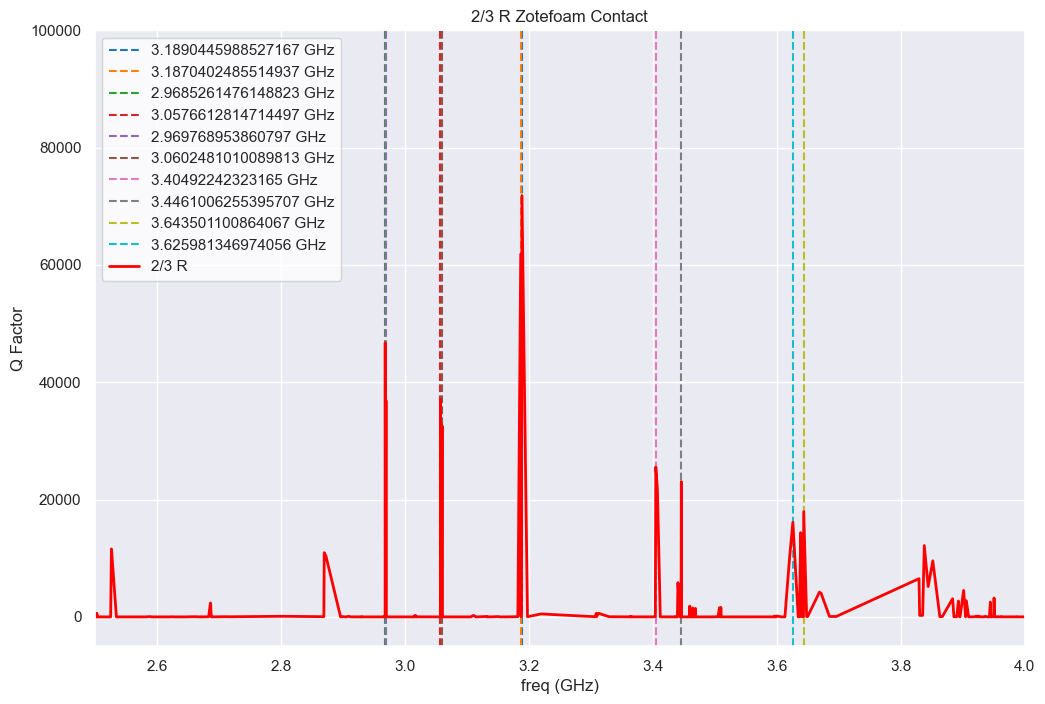

In [86]:
plt.figure(figsize = (12, 8))
cmap = plt.get_cmap('tab10')
for i in range(10):
    color = cmap(i % cmap.N)
    plt.axvline(x=twothirds_R_peaks['freqs'].loc[i], 
                ymin=0, ymax = 100000, 
                label = str(twothirds_R_peaks['freqs'].loc[i]) + ' GHz', 
                ls='dashed', color = color)
plt.plot(twothirds_R_reduced['Frequency (GHz)'], twothirds_R_reduced['Quality factor (1)'], label = '2/3 R', color = 'red', lw = 2)
plt.legend(facecolor='white')
plt.xlim(2.5, 4)
plt.ylim(-5000, 100000)
plt.title('2/3 R Zotefoam Contact')
plt.xlabel('freq (GHz)')
plt.ylabel('Q Factor')

Text(0, 0.5, 'Q Factor')

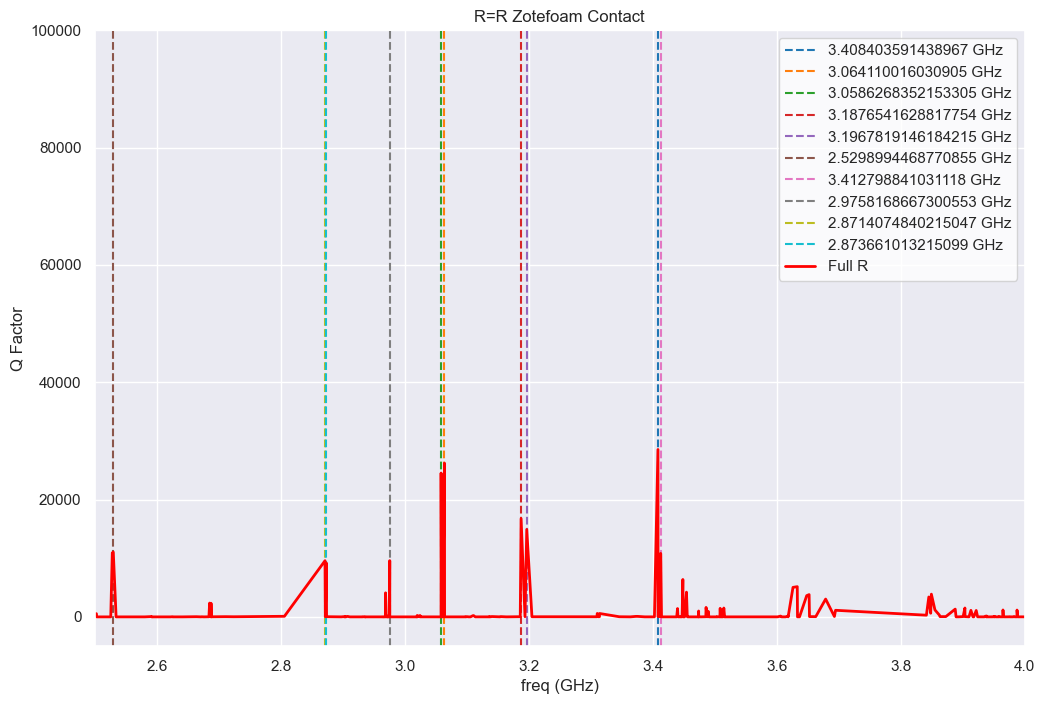

In [87]:
plt.figure(figsize = (12, 8))
cmap = plt.get_cmap('tab10')
for i in range(10):
    color = cmap(i % cmap.N)
    plt.axvline(x=full_R_peaks['freqs'].loc[i], 
                ymin=0, ymax = 100000, 
                label = str(full_R_peaks['freqs'].loc[i]) + ' GHz', 
                ls='dashed', color = color)
plt.plot(full_R_reduced['Frequency (GHz)'], full_R_reduced['Quality factor (1)'], label = 'Full R', color = 'red', lw = 2)
plt.legend(facecolor='white')
plt.xlim(2.5, 4)
plt.ylim(-5000, 100000)
plt.title('R=R Zotefoam Contact')
plt.xlabel('freq (GHz)')
plt.ylabel('Q Factor')

(3.175, 3.215)

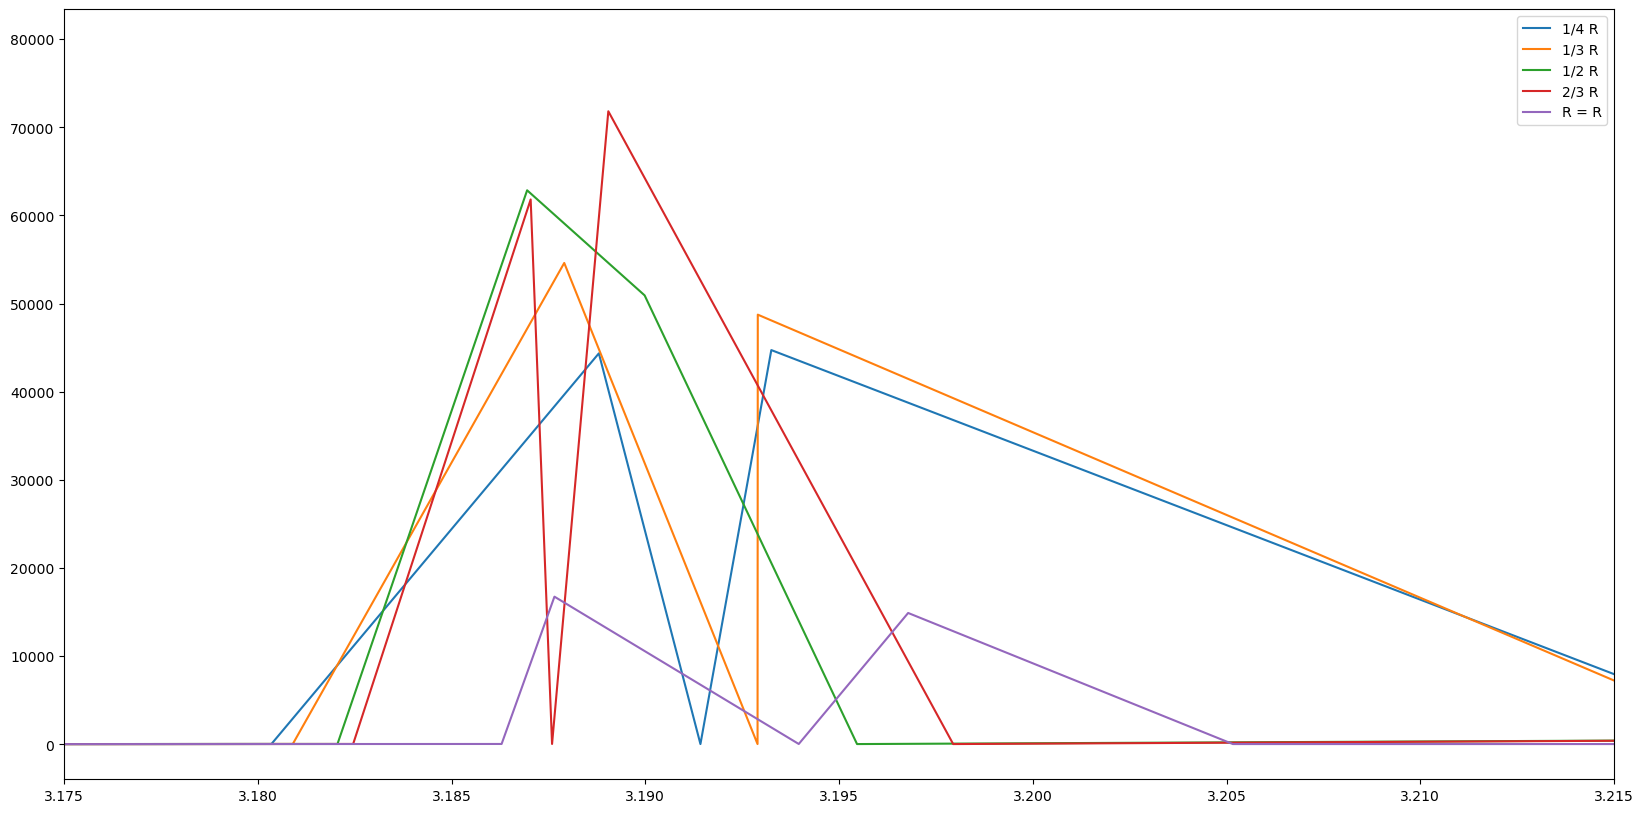

In [37]:
plt.figure(figsize = (20,10))
plt.plot(quarter_R['Frequency (GHz)'], quarter_R['Quality factor (1)'], label = '1/4 R')
plt.plot(third_R['Frequency (GHz)'], third_R['Quality factor (1)'], label = '1/3 R')
plt.plot(half_R['Frequency (GHz)'], half_R['Quality factor (1)'], label = '1/2 R')
plt.plot(twothirds_R['Frequency (GHz)'], twothirds_R['Quality factor (1)'], label = '2/3 R')
plt.plot(full_R['Frequency (GHz)'], full_R['Quality factor (1)'], label = 'R = R')
plt.legend()

plt.xlim(3.175, 3.215)

try gathering the highest-Q points for each radius, and then plotting where those high-Q points end up

(3.39, 3.425)

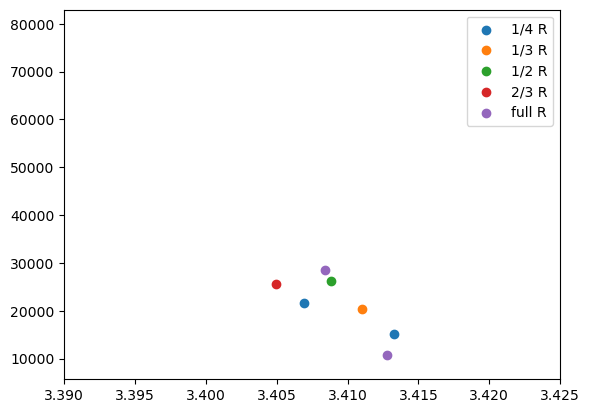

In [43]:
plt.scatter(quarter_R_peaks['freqs'], quarter_R_peaks['Q'], label = '1/4 R')
plt.scatter(third_R_peaks['freqs'], third_R_peaks['Q'], label = '1/3 R')
plt.scatter(half_R_peaks['freqs'], half_R_peaks['Q'], label = '1/2 R')
plt.scatter(twothirds_R_peaks['freqs'], twothirds_R_peaks['Q'], label = '2/3 R')
plt.scatter(full_R_peaks['freqs'], full_R_peaks['Q'], label = 'full R')
plt.legend()
plt.xlim(3.39, 3.425)

In [ ]:
quarter_R_peaks